### PLOTTER NOTEBOOK

In [1]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
import pickle

In [22]:
### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'
    
photrunName = 'test_polar_v0_static.h5'
# photrunName = 'test_polar_v0_dynamic.h5'
# photrunName = 'polar_v1_static_baseline120.h5'
# photrunName = 'jwst_v0_static.h5'

# photrunName = 'test_onlyVortex_v0_static.h5'
# photrunName = 'test_onlyVortex_v0_dynamic.h5'

path = os.path.join(photometryh5dir, photrunName)
results = readPhotometry(path)

### Read codecs and spectra timeseries
specConfigName = f'1200k_clouds=20'
runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
dirPath = os.path.join(os.getcwd(), runname)

### Make plots directory
plotsDir = os.path.join(dirPath, 'plots')
if not os.path.exists(plotsDir):
    os.makedirs(plotsDir)

# Search for files matching the pattern 'i=*.h5' in the directory
spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

# Initialize the specs dictionary
specs = {}
codecs = {}

# Iterate through each file and load spectra
for index, file in enumerate(spectra_files):
    inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename
    
    specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
    codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

# Load the json config codec_config.json
configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
codec_loaded = CodecSystem()
codec_loaded.import_mapping(configPath, validate_files=False)

# Load the full picaso result summary
### Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
specFolderName = 'bd_grid_noCH4_20251209_153457'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20

Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_1.00_cloudy', 'bd_1200_10000_1.0E+07_1.01_cloudy', 'bd_1200_10000_1.0E+07_1.02_cloudy', 'bd_1200_10000_1.0E+07_1.03_cloudy', 'bd_1200_10000_1.0E+07_1.04_cloudy', 'bd_1200_10000_1.0E+07_1.05_cloudy', 'bd_1200_10000_1.0E+07_1.06_cloudy', 'bd_1200_10000_1.0E+07_1.07_cloudy', 'bd_1200_10000_1.0E+07_1.08_cloudy', 'bd_1200_10000_1.0E+07_1.09_cloudy', 'bd_1200_10000_1.0E+07_1.10_cloudy', 'bd_1200_10000_1.0E+07_1.11_cloudy', 'bd_1200_10000_1.0E+07_1.12_cloudy', 'bd_1200_10000_1.0E+07_1.13_cloudy', 'bd_1200_10000_1.0E+07_1.14_cloudy', 'bd_1200_10000_1.0E+07_1.15_cloudy', '

In [23]:
# codec_loaded.print_all_combinations()
print(codec_loaded.spectra_assignments.keys())
for i in range(len(codec_loaded.spectra_assignments.keys())):
    codec_loaded.print_combination(i)

fsed_list =[]
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))
print(fsed_list)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

Codec ID 0:
  cloud_thickness: 1  (Cloud optical depth levels)
  Spectra: /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/bd_grid_noCH4_20251209_153457/spec_1200_10000_1.0E+07_1.00_cloudy.csv

Codec ID 1:
  cloud_thickness: 2  (Cloud optical depth levels)
  Spectra: /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/bd_grid_noCH4_20251209_153457/spec_1200_10000_1.0E+07_1.01_cloudy.csv

Codec ID 2:
  cloud_thickness: 3  (Cloud optical depth levels)
  Spectra: /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/bd_grid_noCH4_20251209_153457/spec_1200_10000_1.0E+07_1.02_cloudy.csv

Codec ID 3:
  cloud_thickness: 4  (Cloud optical depth levels)
  Spectra: /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/bd_grid_noCH4_20251209_153457/spec_1200_10000_1.0E+07_1.03_cloudy.csv

Codec ID 4:
  cloud_thickness: 5  (Cloud optical depth levels)
  Spectra: /Users/nguyenda

### Necessary Metadata

In [24]:
### Somes helpful metadata
# codec length
n = len(codec_loaded.spectra_assignments.keys())
# how to load a spectrum
wave, flux = codec_loaded.load_spectrum(codec_id=0)
print(wave[::50])
print(flux[::50])
# load the time indices 
time_indices = results['0']['time_array']

[0.99957438 1.07358431 1.15307404 1.23844931 1.33014588 1.42863181
 1.53440977 1.64801968 1.77004144 1.90109786 2.04185789 2.19304
 2.35541585 2.52981424 2.71712533 2.91830522 3.13438075 3.36645482
 3.615712   3.88342454 4.1709589  4.47978271 4.81147229 5.16772065
 5.55034615 5.96130179]
[2.45420234e-09 4.41506495e-09 6.82549022e-09 1.23148160e-08
 1.89032672e-08 1.73741067e-08 4.20557653e-08 5.93475747e-08
 7.22594861e-08 8.30731523e-08 1.26519555e-07 1.60537524e-07
 1.92009615e-07 1.51329476e-07 1.50701667e-07 2.40656328e-07
 3.19187019e-07 3.50685914e-07 3.76756954e-07 3.81990088e-07
 4.33680206e-07 4.61880014e-07 4.49066258e-07 4.46483576e-07
 2.70172383e-07 4.42915717e-07]


{'0': 0.0028143127907644594, '1': 0.022787318361955085, '2': 0.0018809947734191028, '3': 0.0006174257653207742, '4': 0.0005312733329504337, '5': 0.0007179369364195049, '6': 0.12981735684337486, '7': 0.003819424501751766, '8': 0.0039055769341221065, '9': 0.005183504680948825, '10': 0.7163861926368388, '11': 0.005599908104072139, '12': 0.0050399172936649245, '13': 0.005312733329504336, '14': 0.006461432427775545, '15': 0.007581414048589972, '16': 0.008730113146861179, '17': 0.011070587559588766, '18': 0.015636666475216818, '19': 0.046105910056860606}


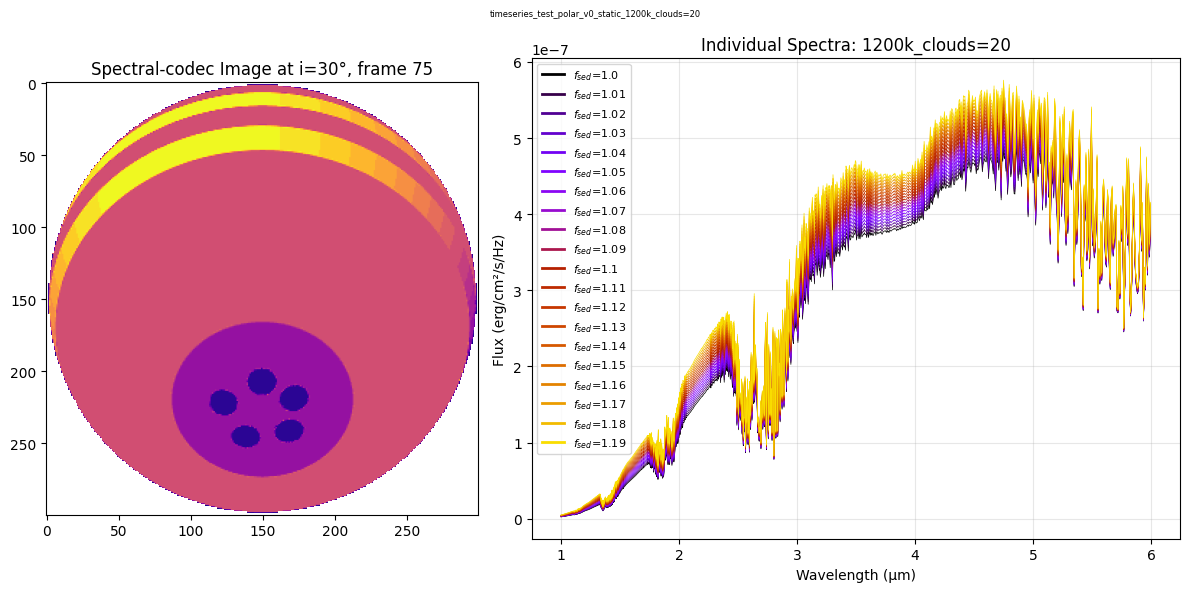

In [25]:
# ===== Plot all codecs spectra with an example image =====

save = False
# save = True

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1, 1.5])
fig.suptitle(runname, fontsize=6)

ax = axes[0]
frame_id = 75
ax.imshow(codecs['30'][frame_id]['composite'], cmap='plasma')
ax.set_title(f'Spectral-codec Image at i=30°, frame {frame_id}')
print(codecs['30'][frame_id]['fractions']['fractions'])

# ===== Plot 1: All individual spectra =====
ax = axes[1]
for codec_id in range(n):  # Plot all codec
    wave_i, flux_i = codec_loaded.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, color=plt.cm.gnuplot(codec_id / n))
    ax.plot([], [], lw=2, color=plt.cm.gnuplot(codec_id / n), 
            label=r'$f_{sed}$='+f'{fsed_list[codec_id][1]}')  # For legend
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux (erg/cm²/s/Hz)')
ax.set_title('Individual Spectra: '+specConfigName)
ax.legend(fontsize=8)
ax.set_yscale('linear')
ax.grid(True, alpha=0.3)

plt.tight_layout()
handle = f'all_codecs_{specConfigName}.pdf'
save_path = os.path.join(dirPath, 'plots', handle)
if save:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

plt.close(fig)

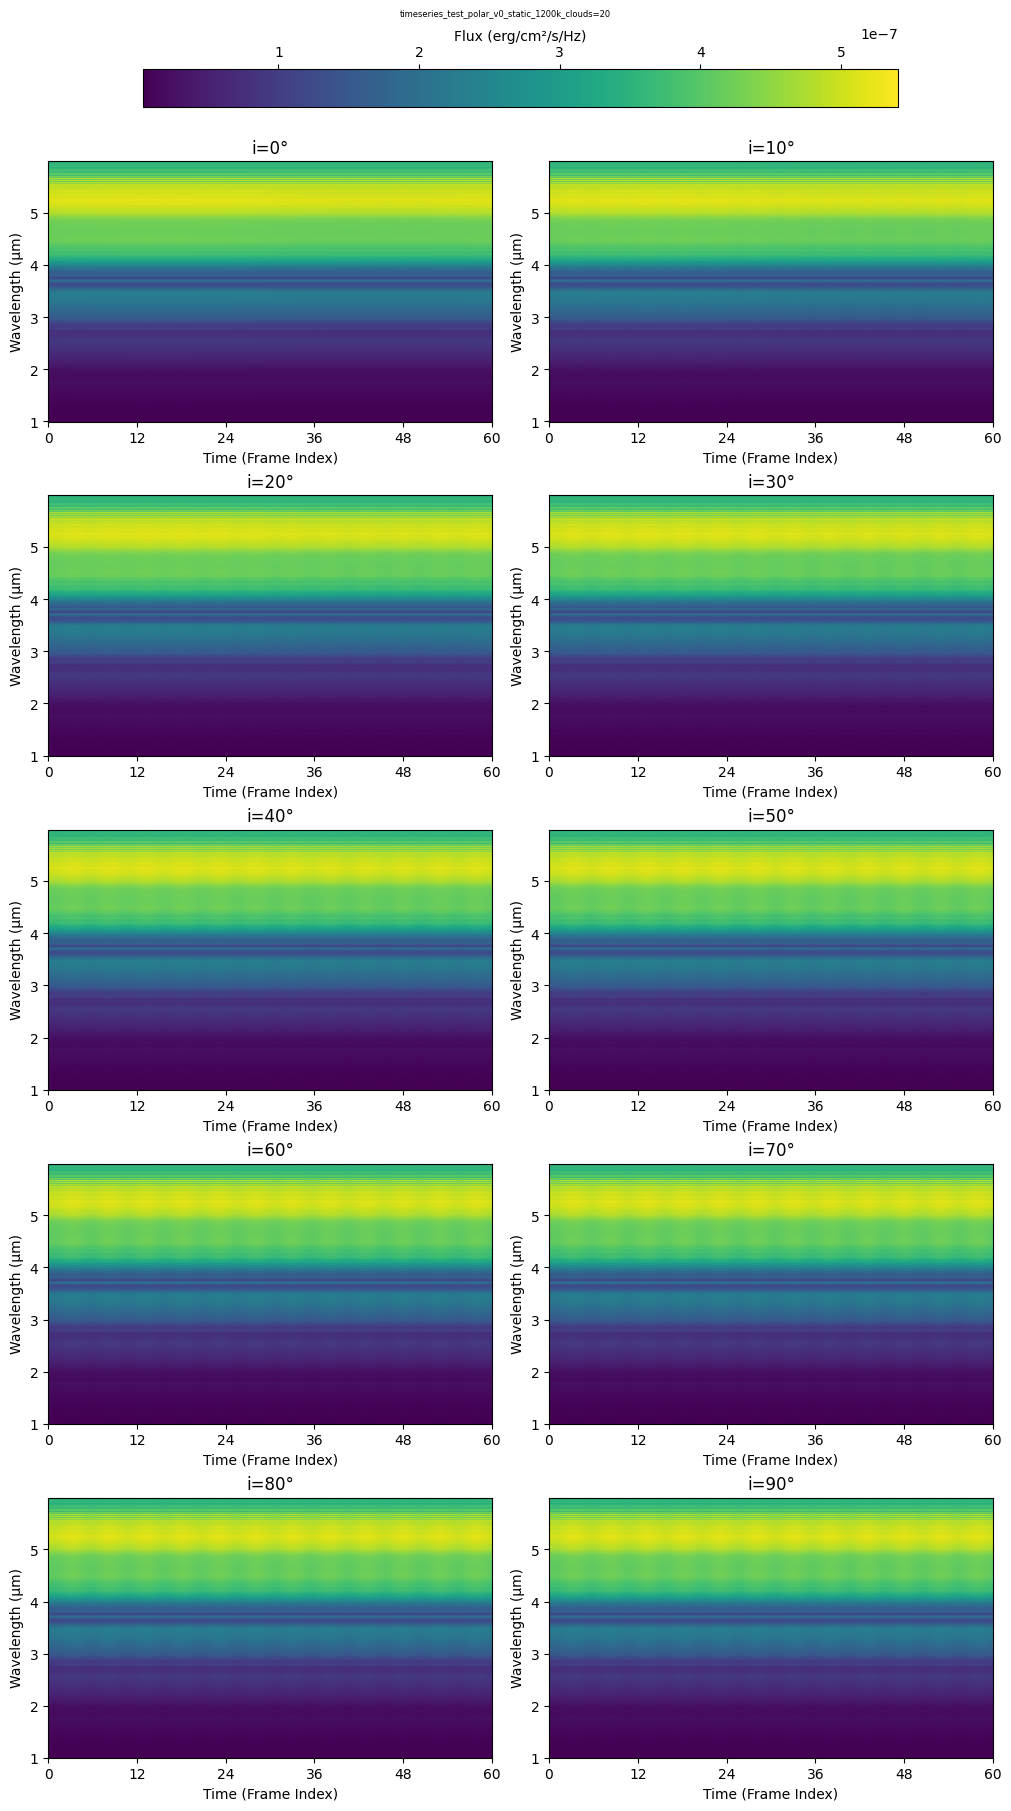

In [26]:
# ===== Plot: 2D image of spectra over time =====
save = False
# save = True 

fig, axes = plt.subplots(5, 2, figsize=(10, 18), constrained_layout=True)
fig.suptitle(runname, fontsize=6)
axes = axes.flatten()

for idx, inclin in enumerate(specs.keys()):
    if idx >= 10:  # Limit to 10 plots
        break
    ax = axes[idx]
    # Prepare data for the 2D image
    time_indices = results[inclin]['time_array']
    time_indices.sort()
    flux_matrix = []
    for keys in specs[inclin].keys():
        _, wave_i, flux_i = specs[inclin][keys].values()
        flux_matrix.append(flux_i)

    flux_matrix = np.array(flux_matrix)

    # Plot the 2D image
    im = ax.imshow(flux_matrix.T, aspect='auto', origin='lower', 
                    extent=[time_indices[0], time_indices[-1], wave_i[0], wave_i[-1]],
                    cmap='viridis')

    ax.set_xlabel('Time (Frame Index)')
    ax.set_xticks([])
    ax.set_xticks(np.linspace(time_indices[0], time_indices[-1], num=6, dtype=int))
    ax.set_ylabel('Wavelength (μm)')
    ax.set_title(f'i={inclin}°')

# Add a colorbar to the right of the figure
cbar = fig.colorbar(im, ax=axes, location='top', shrink=0.8, pad=0.02)
cbar.set_label('Flux (erg/cm²/s/Hz)')

# plt.tight_layout()
handle = f'2d_TimeSpectra_image.pdf'
save_path = os.path.join(dirPath, 'plots', handle)
if save:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


### 1 - Plot all cloud codec images

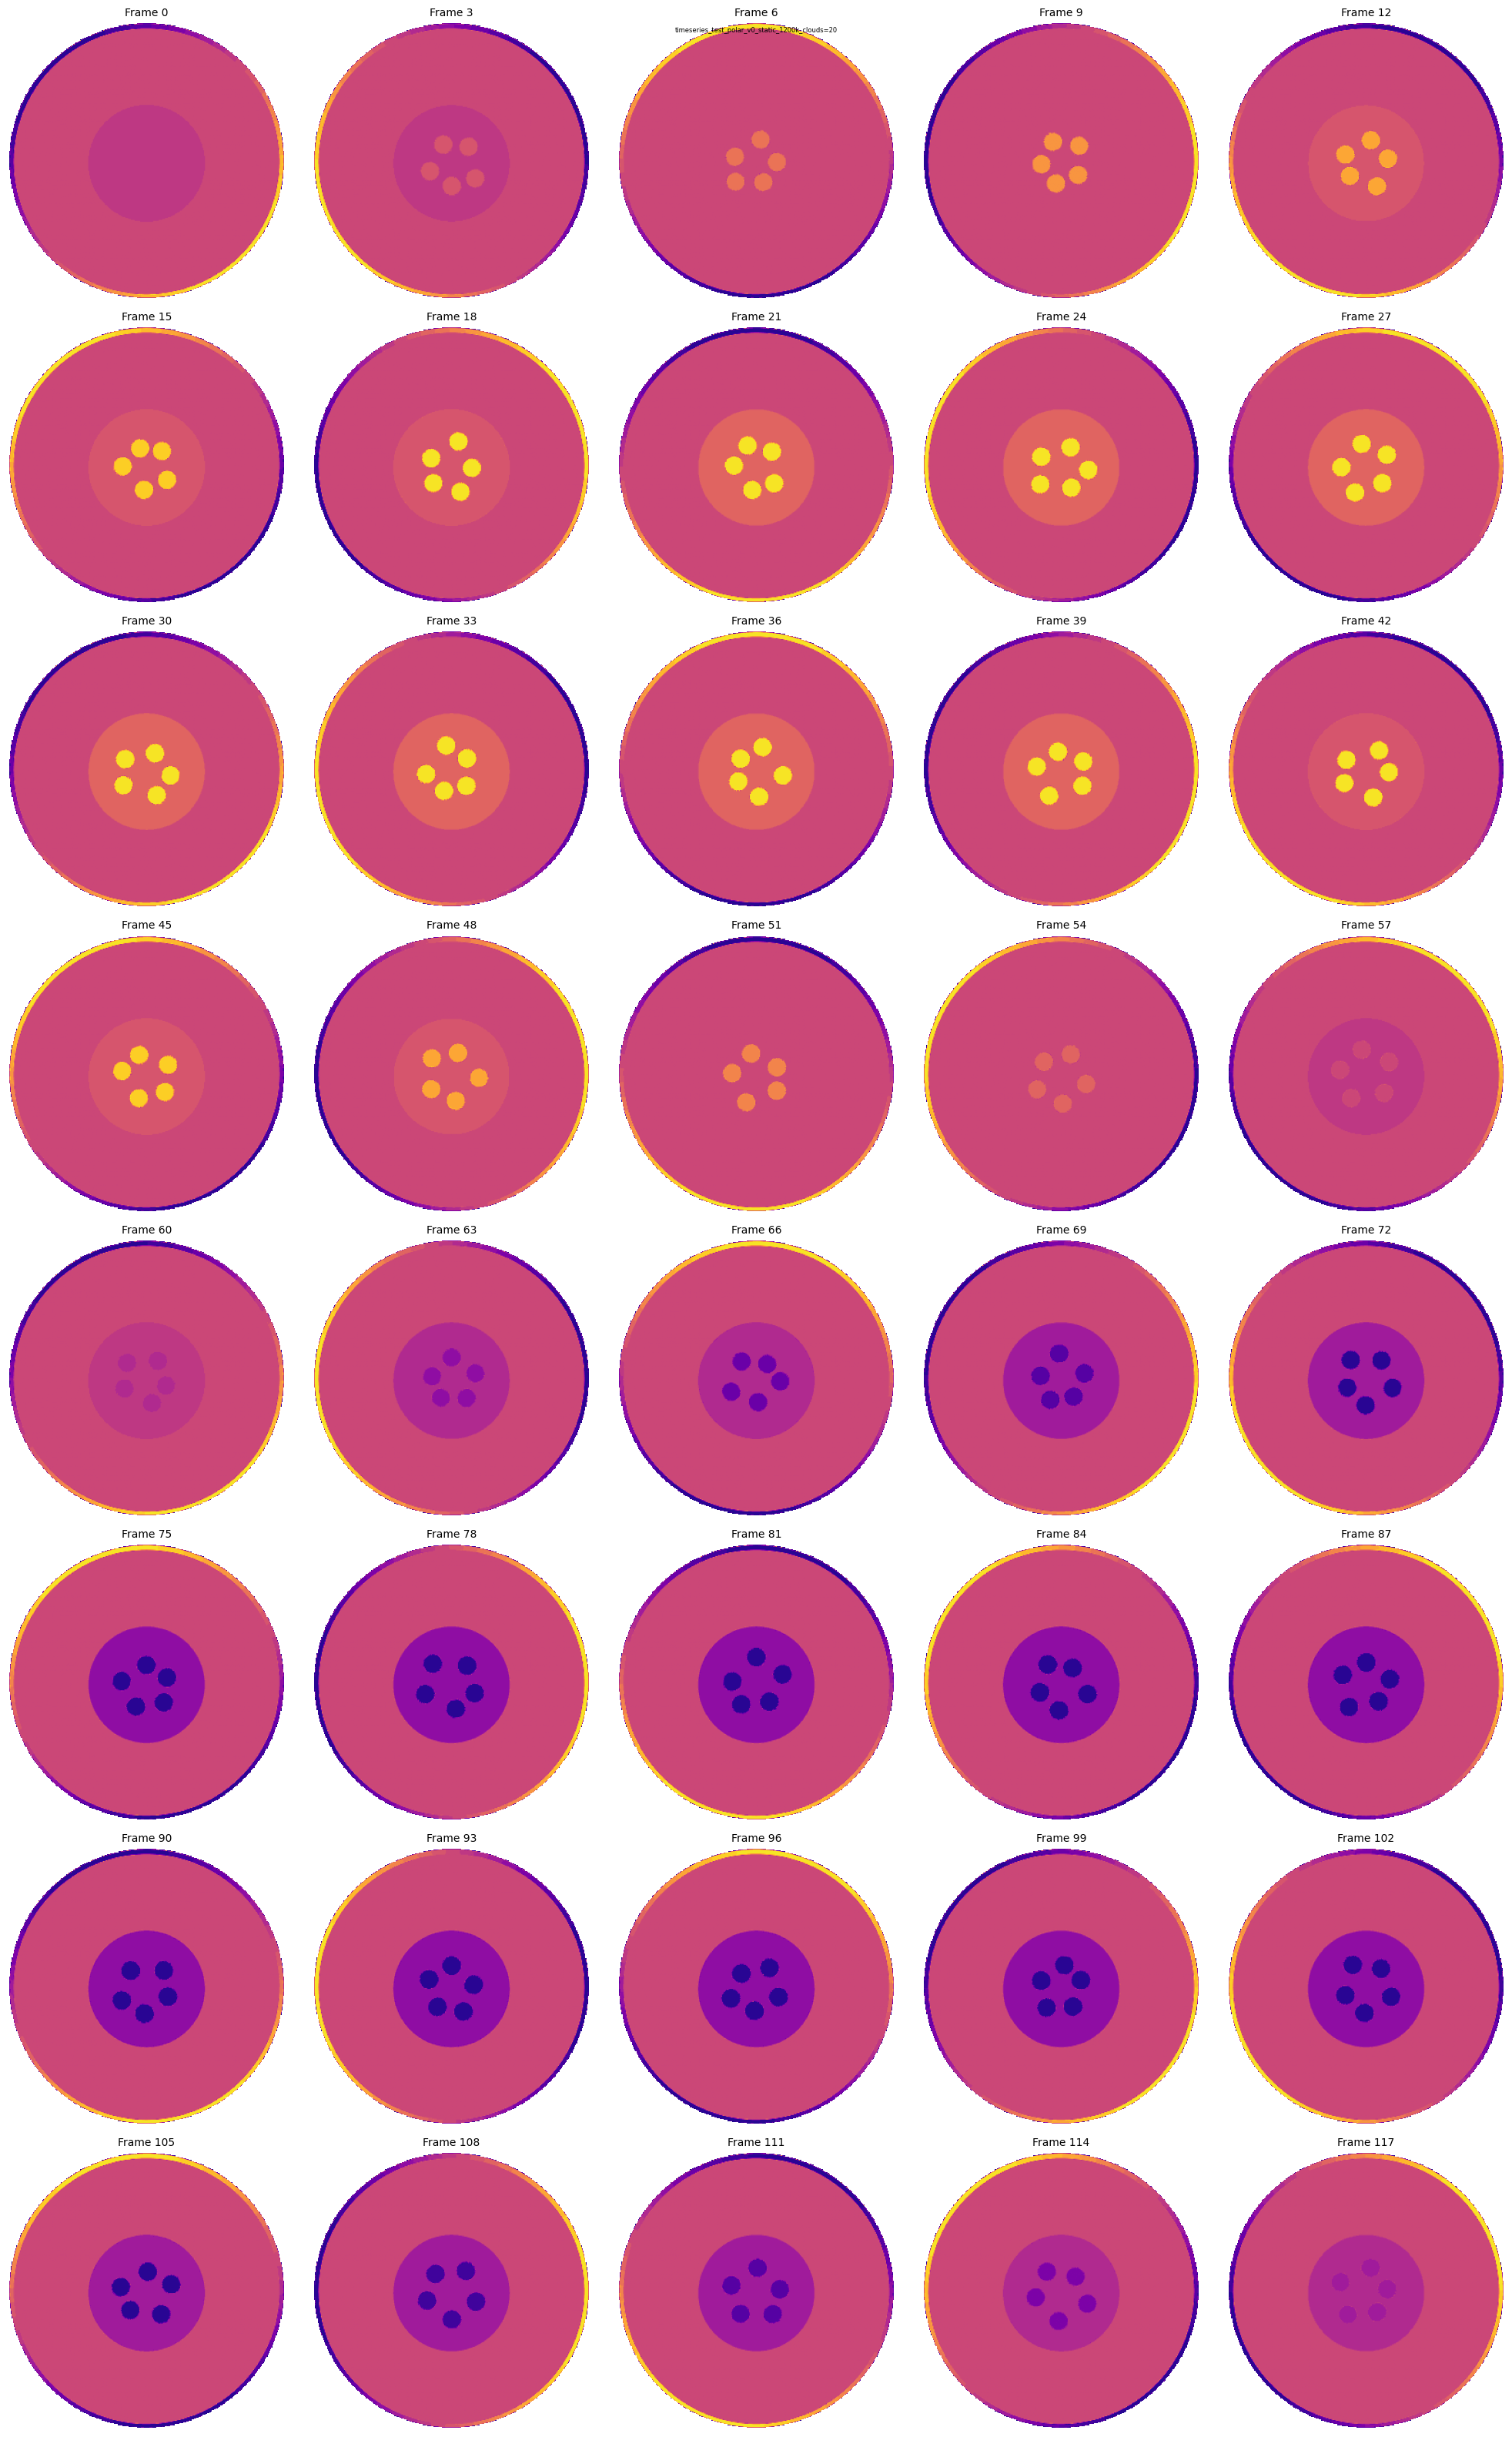

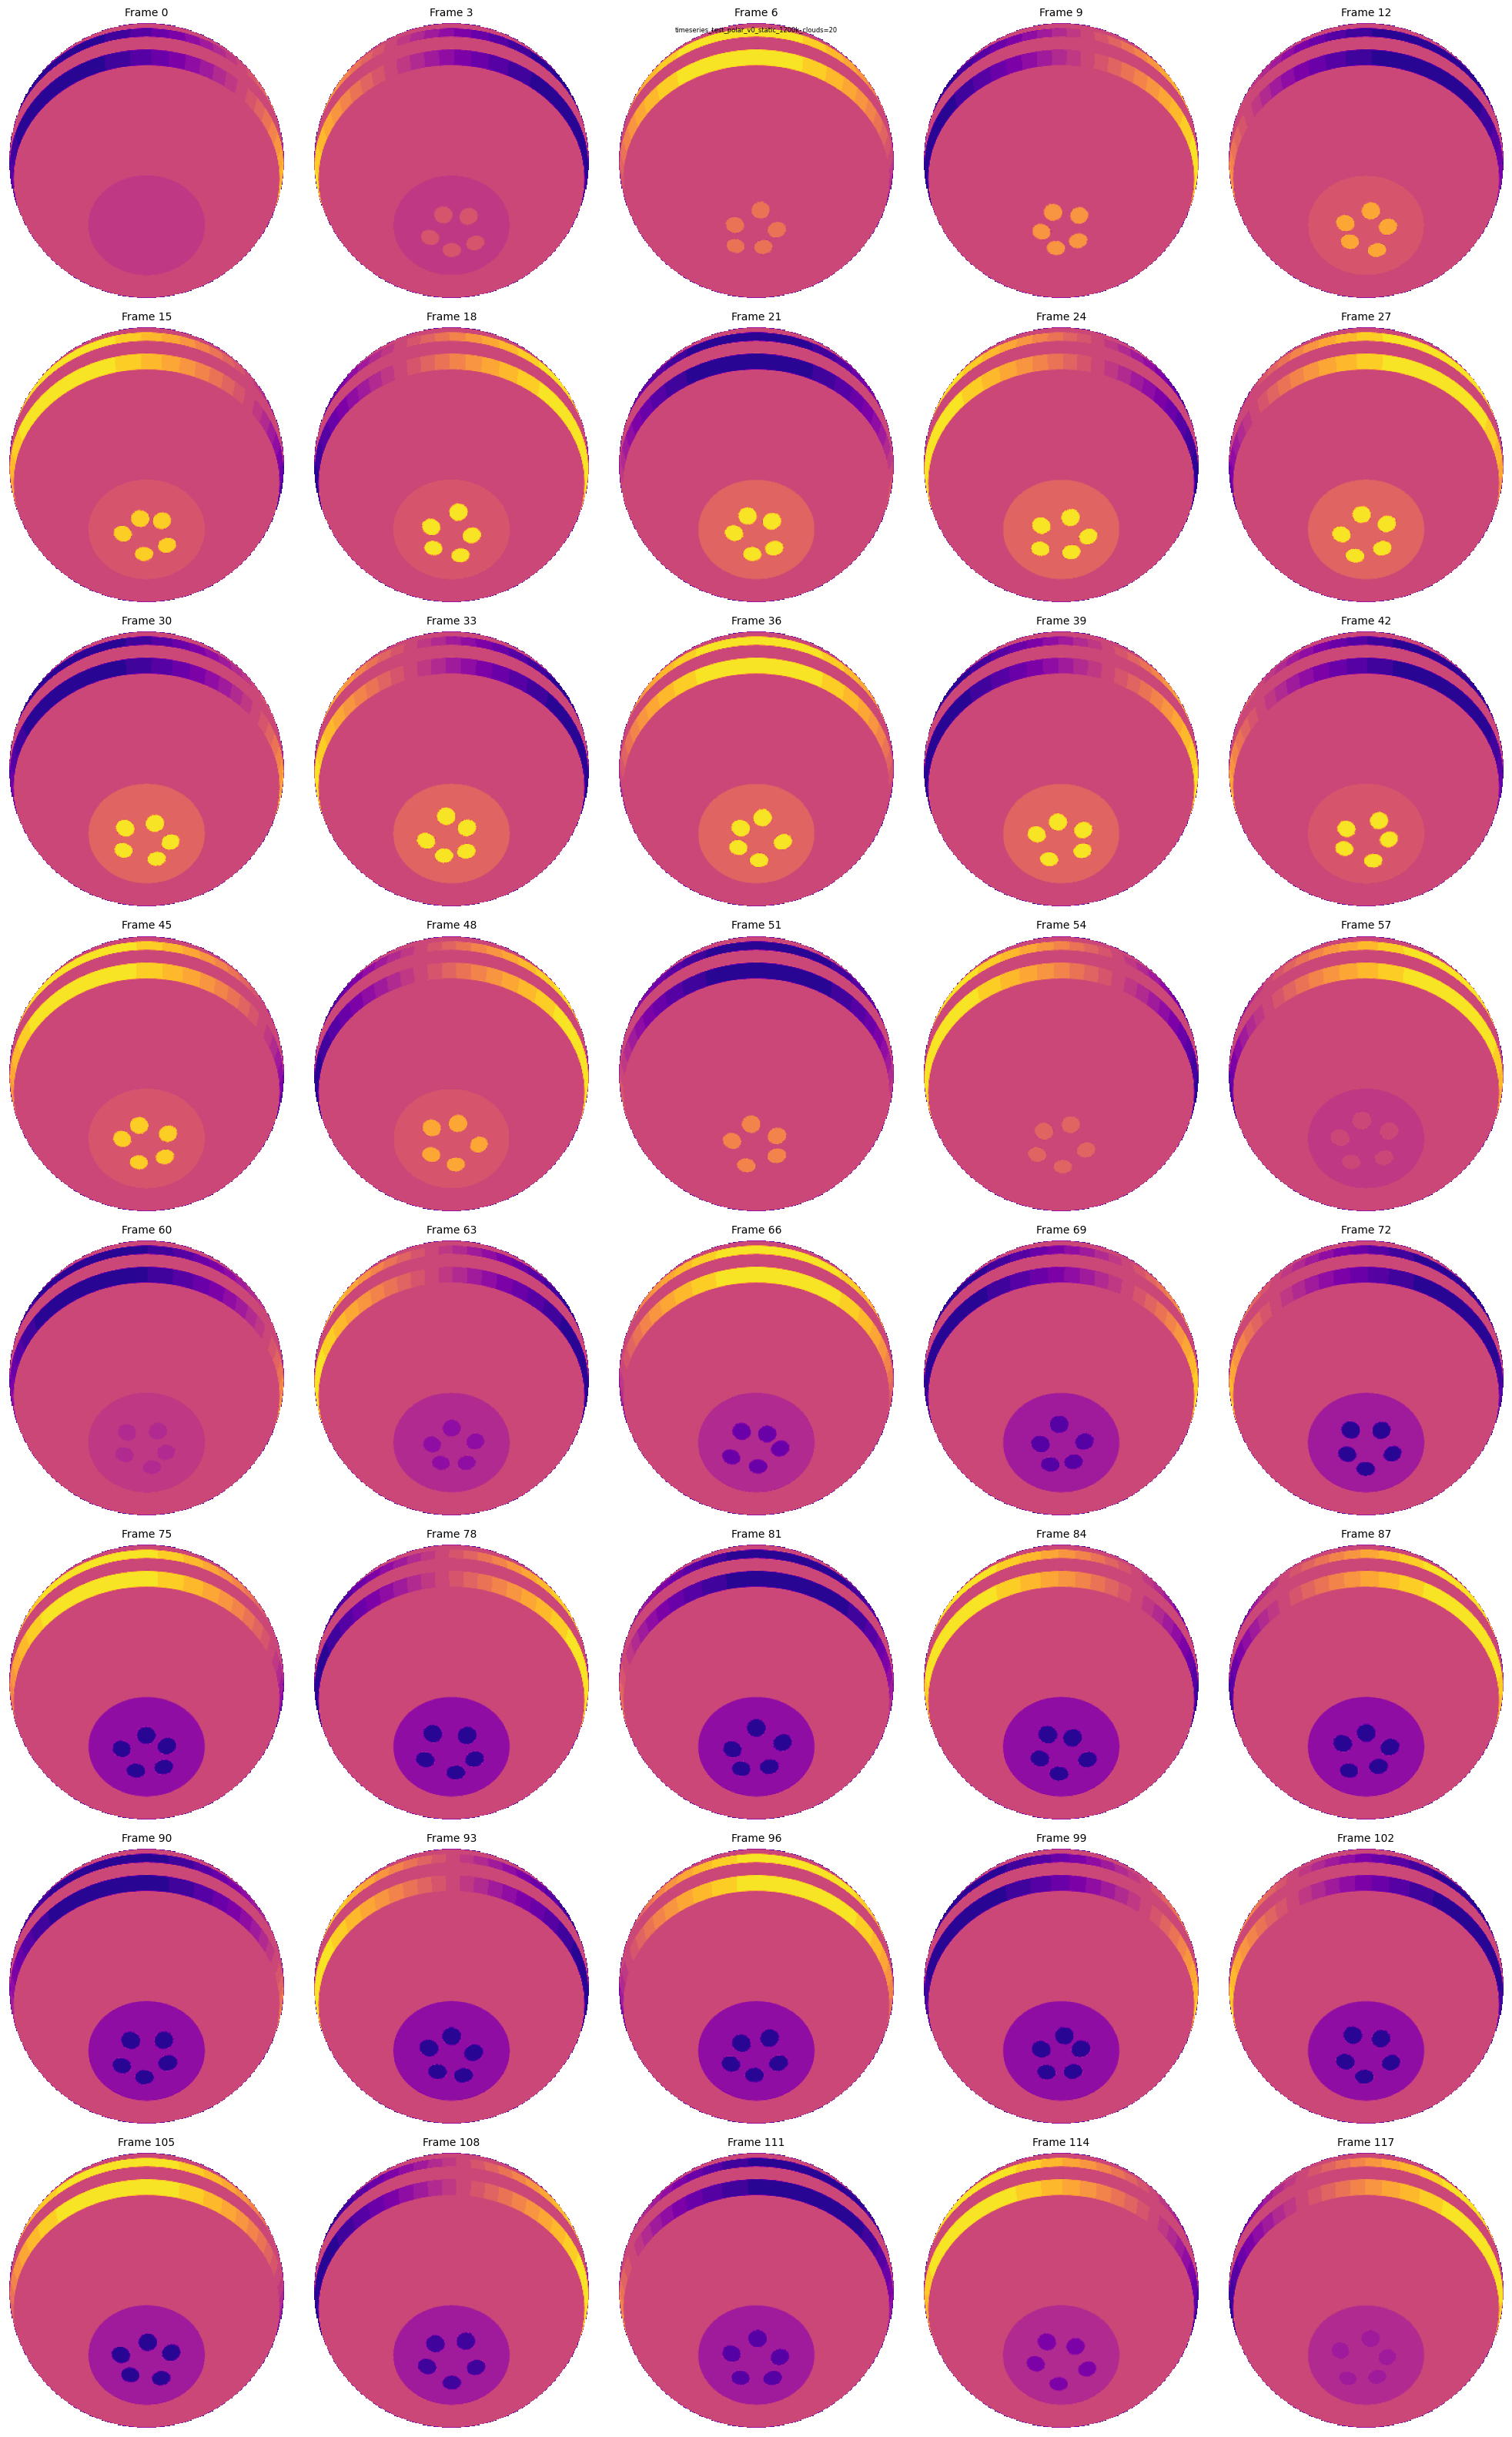

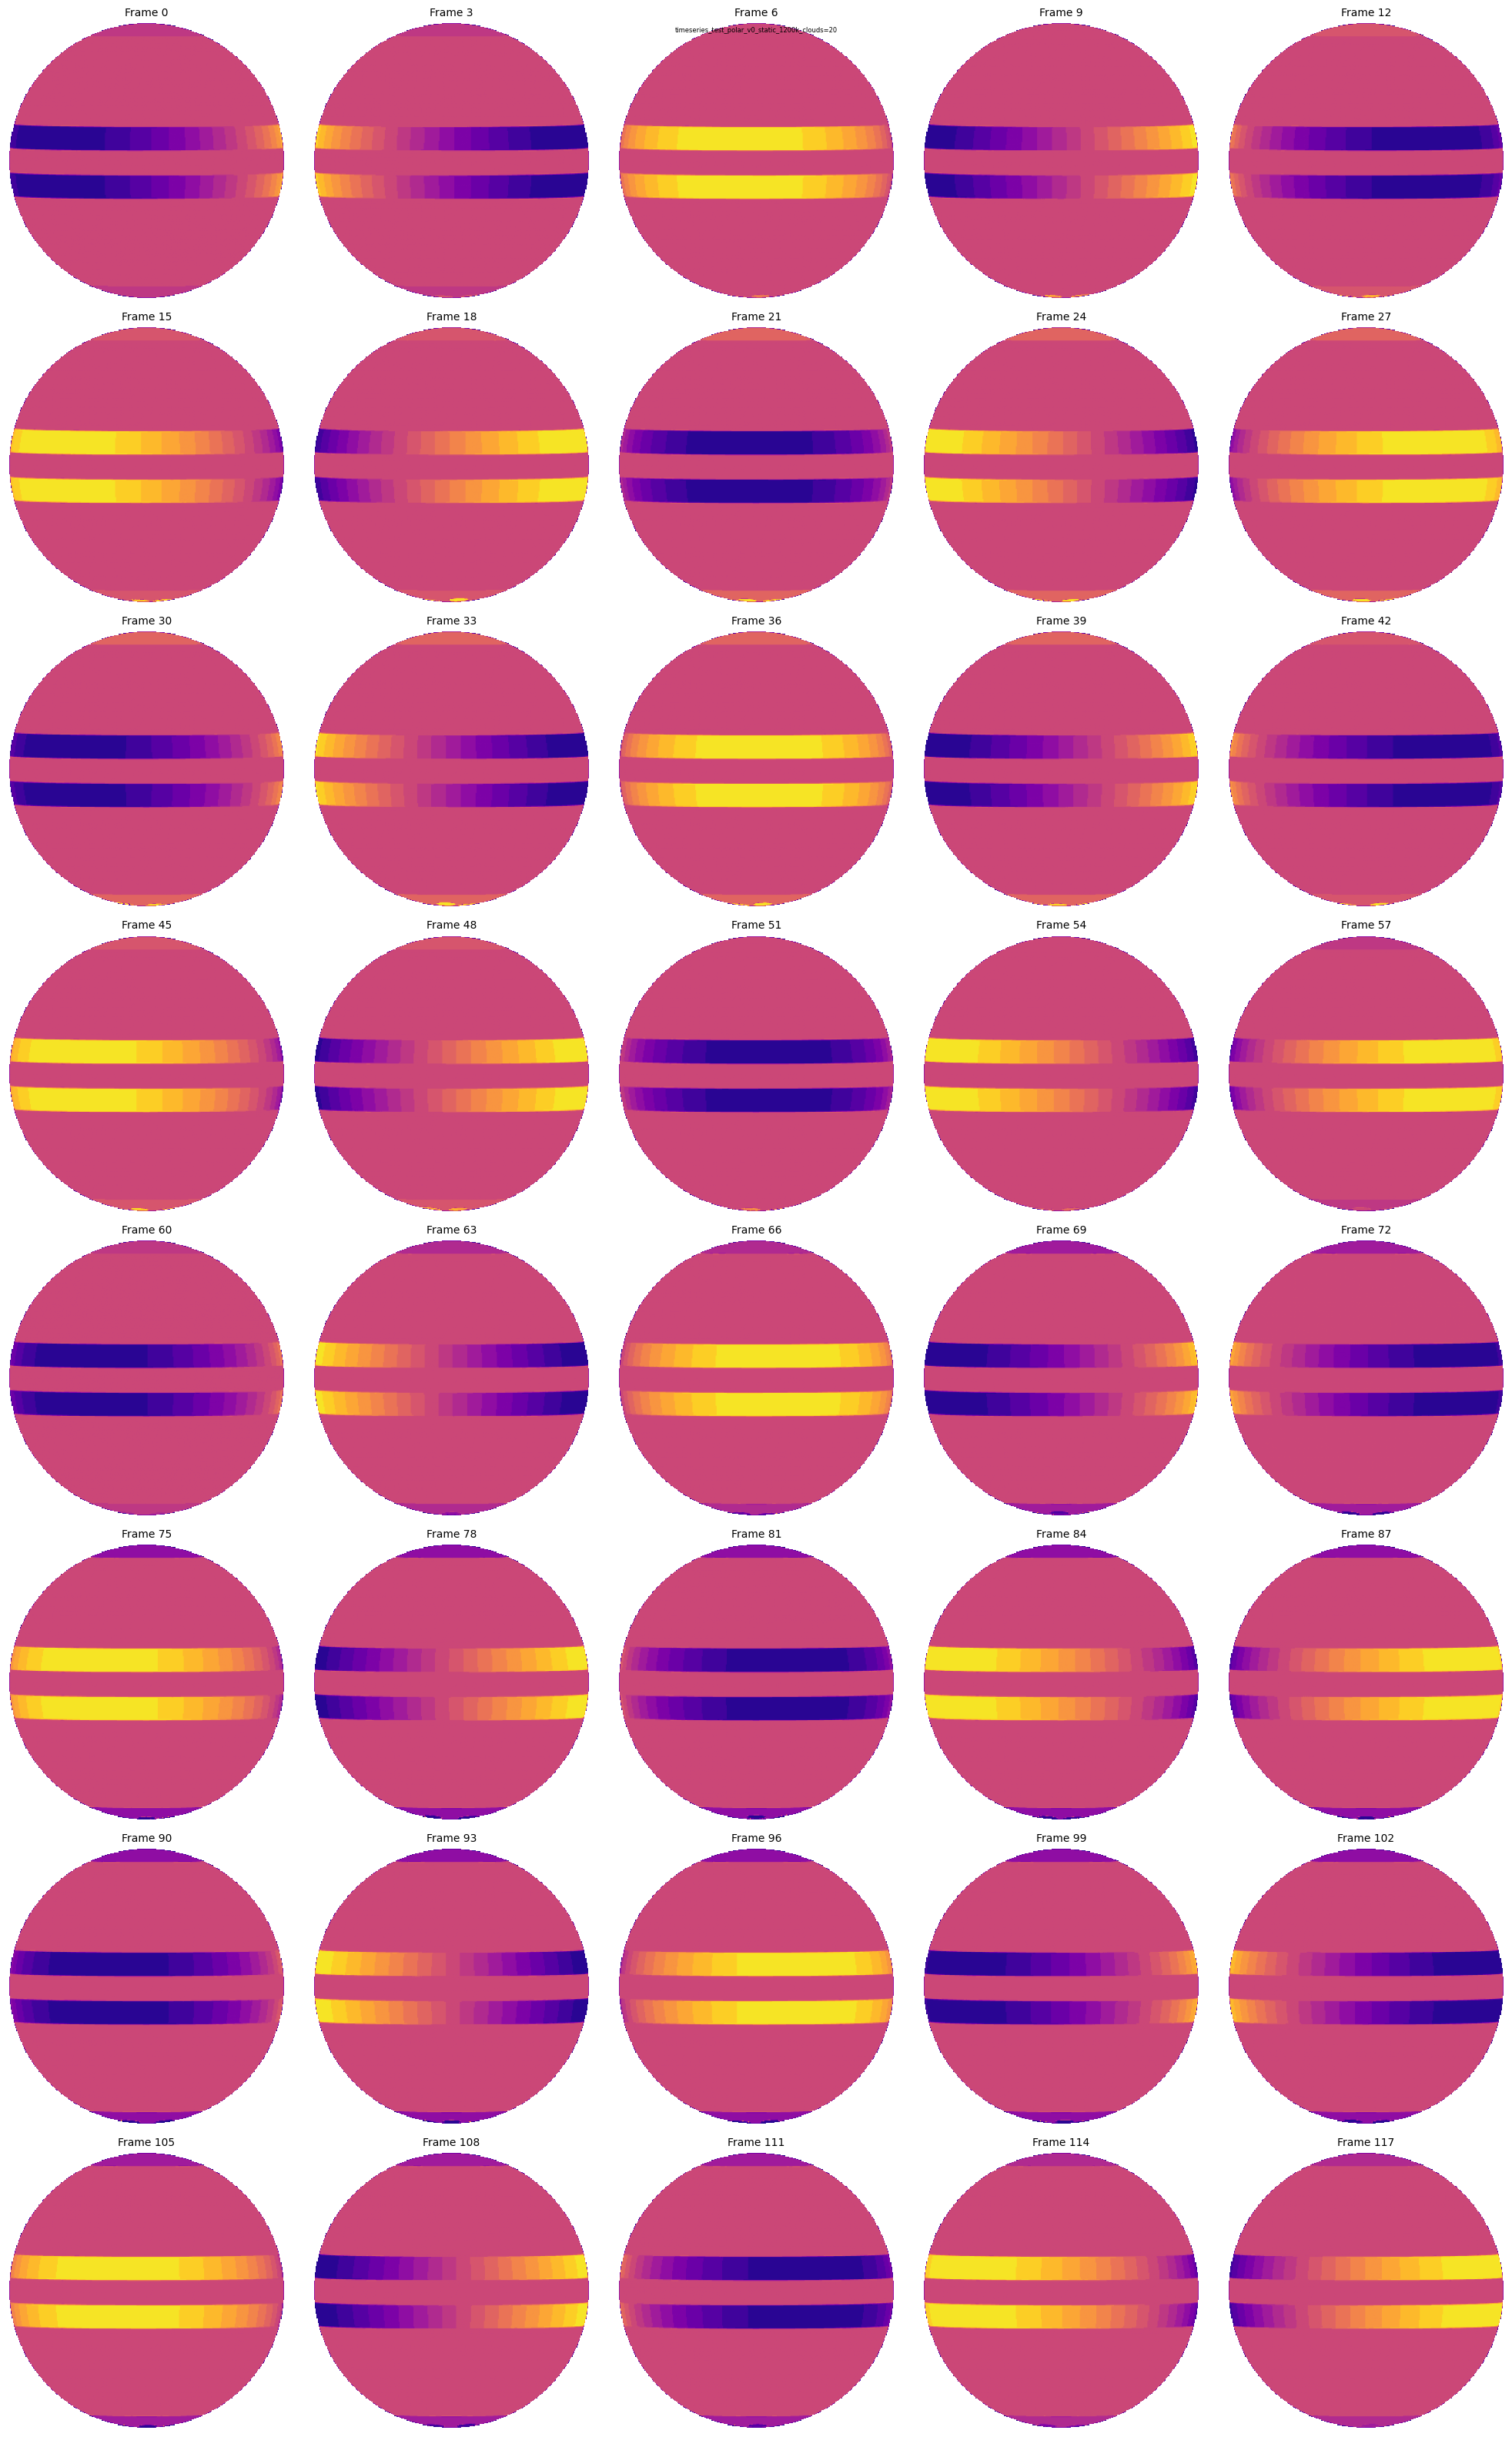

In [27]:
save = False
# save = True
######## Plot all composite images in a grid (5 columns)

# for inc in codecs.keys():
for inc in ['0', '30', '90']:    
    codecs_ts = codecs[inc]
    
    n_frames = 40
    n_cols = 5
    n_rows = int(np.ceil(n_frames / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    fig.suptitle(runname, fontsize=6)

    # Flatten axes for easier indexing
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    # Plot each frame
    for j in range(n_frames):
        i = 3*j  # Select every nth frame for visibility
        ax = axes_flat[j]
        composite = codecs_ts[i]['composite']
        frame_idx = codecs_ts[i]['frame']
        
        im = ax.imshow(composite, cmap='plasma', vmin=0, vmax=n)
        ax.set_title(f'Frame {frame_idx}', fontsize=10)
        ax.axis('off')
        
        # Add colorbar
        # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused subplots
    for i in range(n_frames, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    if save:
        outpath = os.path.join(dirPath, f'all_frames_i={inc}.pdf')
        plt.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"Saved {n_frames}-panel image for i={inc}")
    plt.show()
    plt.close()

### 2 - 2x3 Plot the summary panel: Spectra, Lightcurve, Periodogram, Images


### Visualizing Spectra ###
Saved summary panel for i=0 to spectra_analysis_i=0.pdf


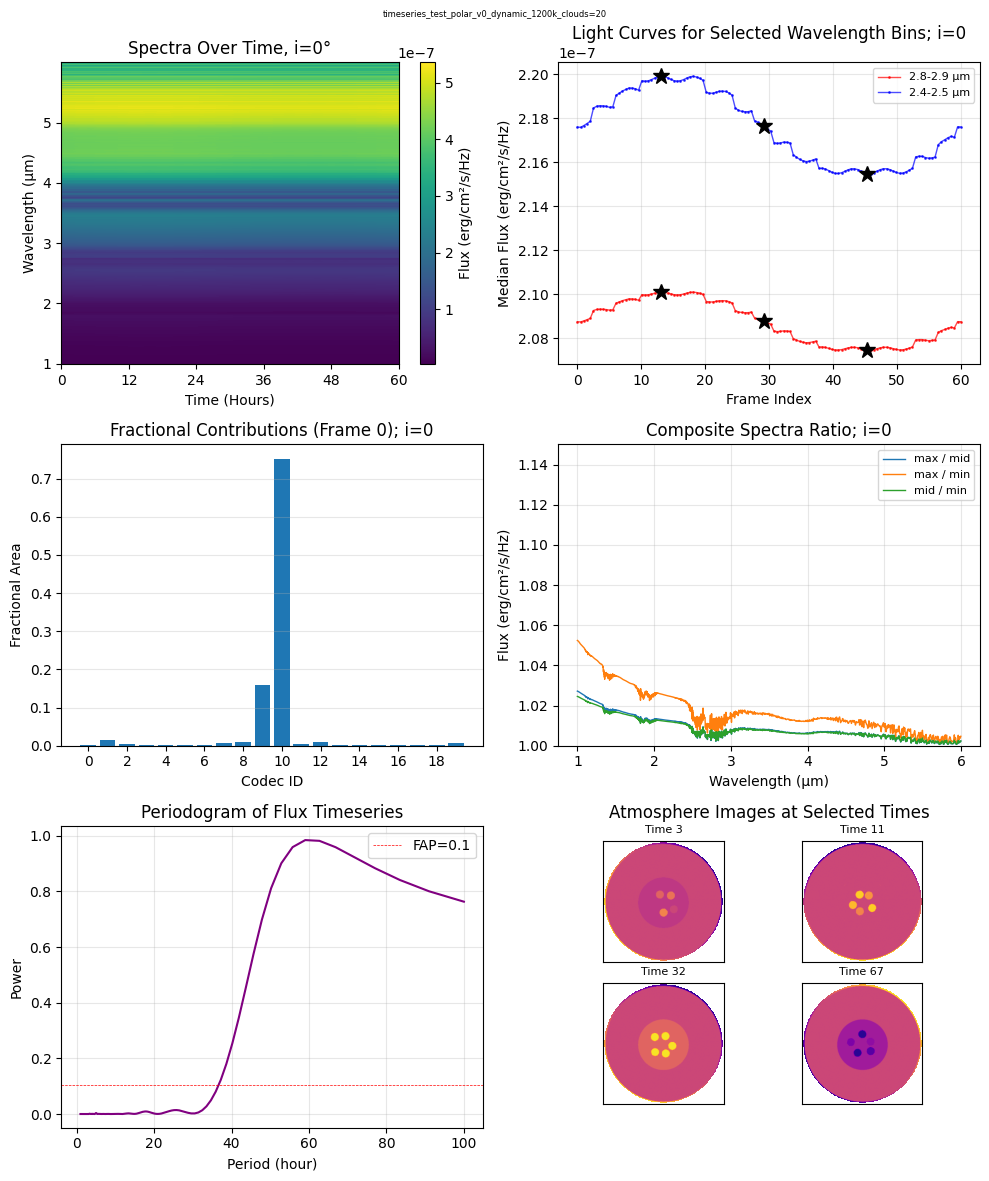


### Visualizing Spectra ###
Saved summary panel for i=10 to spectra_analysis_i=10.pdf


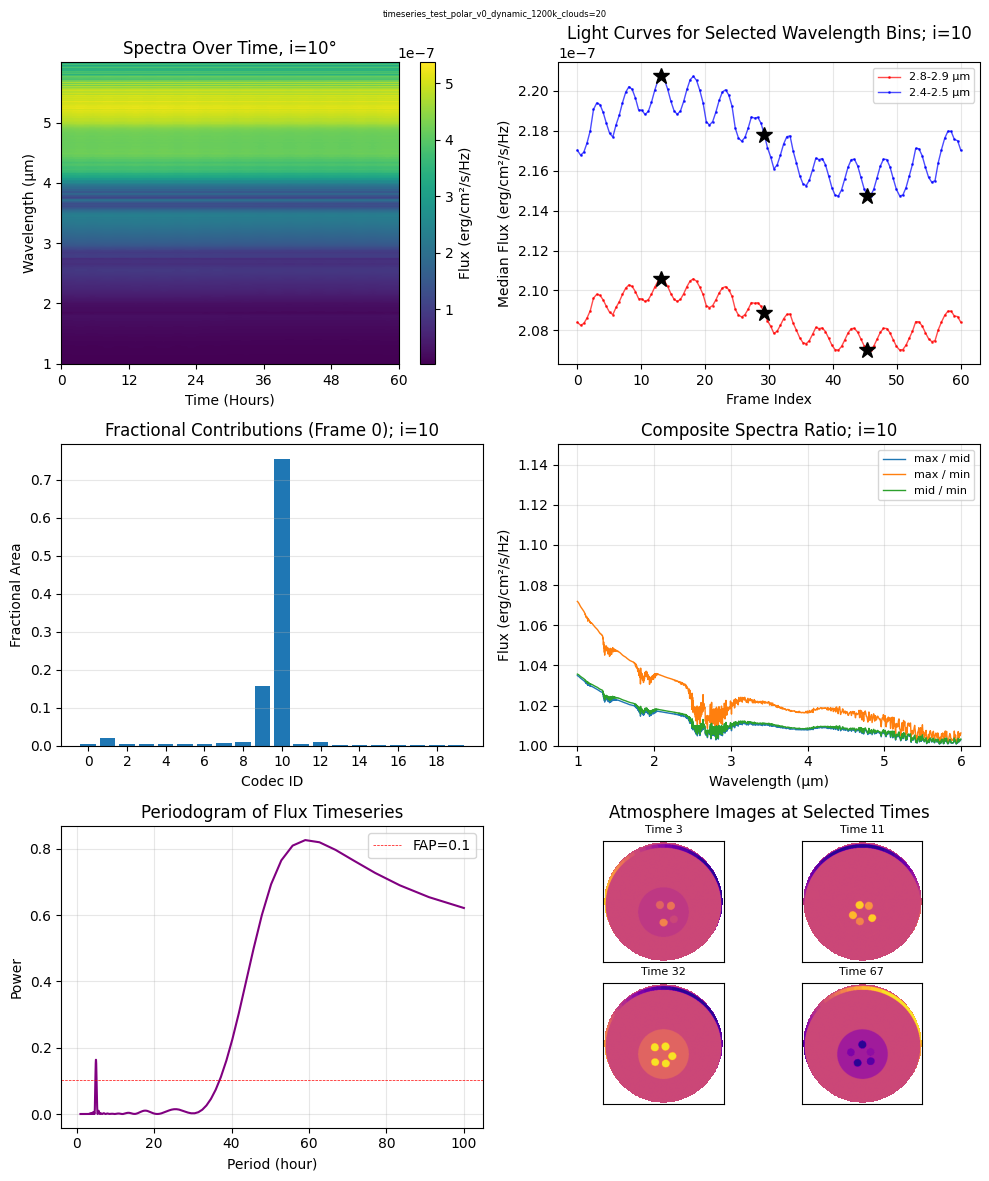


### Visualizing Spectra ###
Saved summary panel for i=20 to spectra_analysis_i=20.pdf


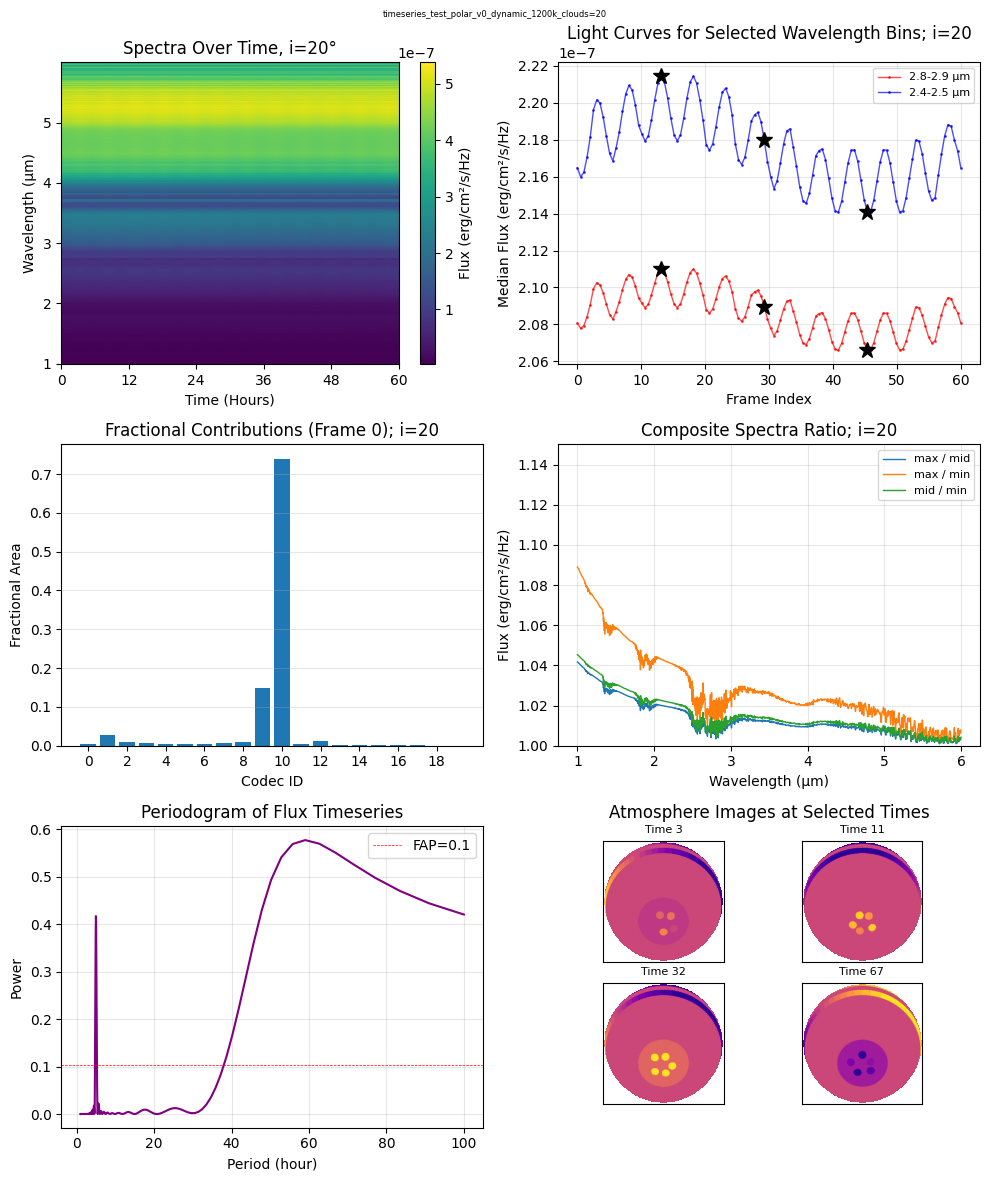


### Visualizing Spectra ###
Saved summary panel for i=30 to spectra_analysis_i=30.pdf


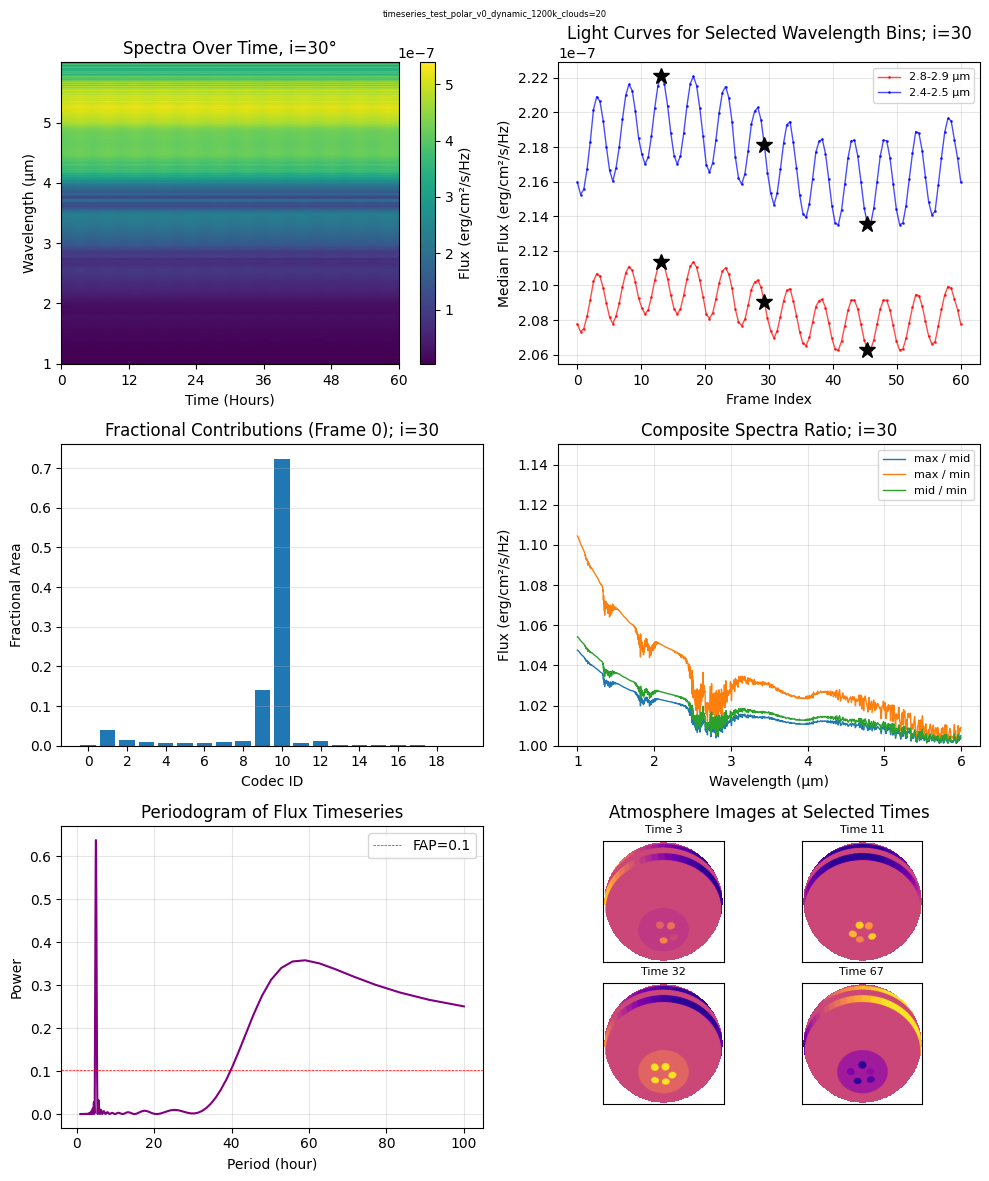


### Visualizing Spectra ###
Saved summary panel for i=40 to spectra_analysis_i=40.pdf


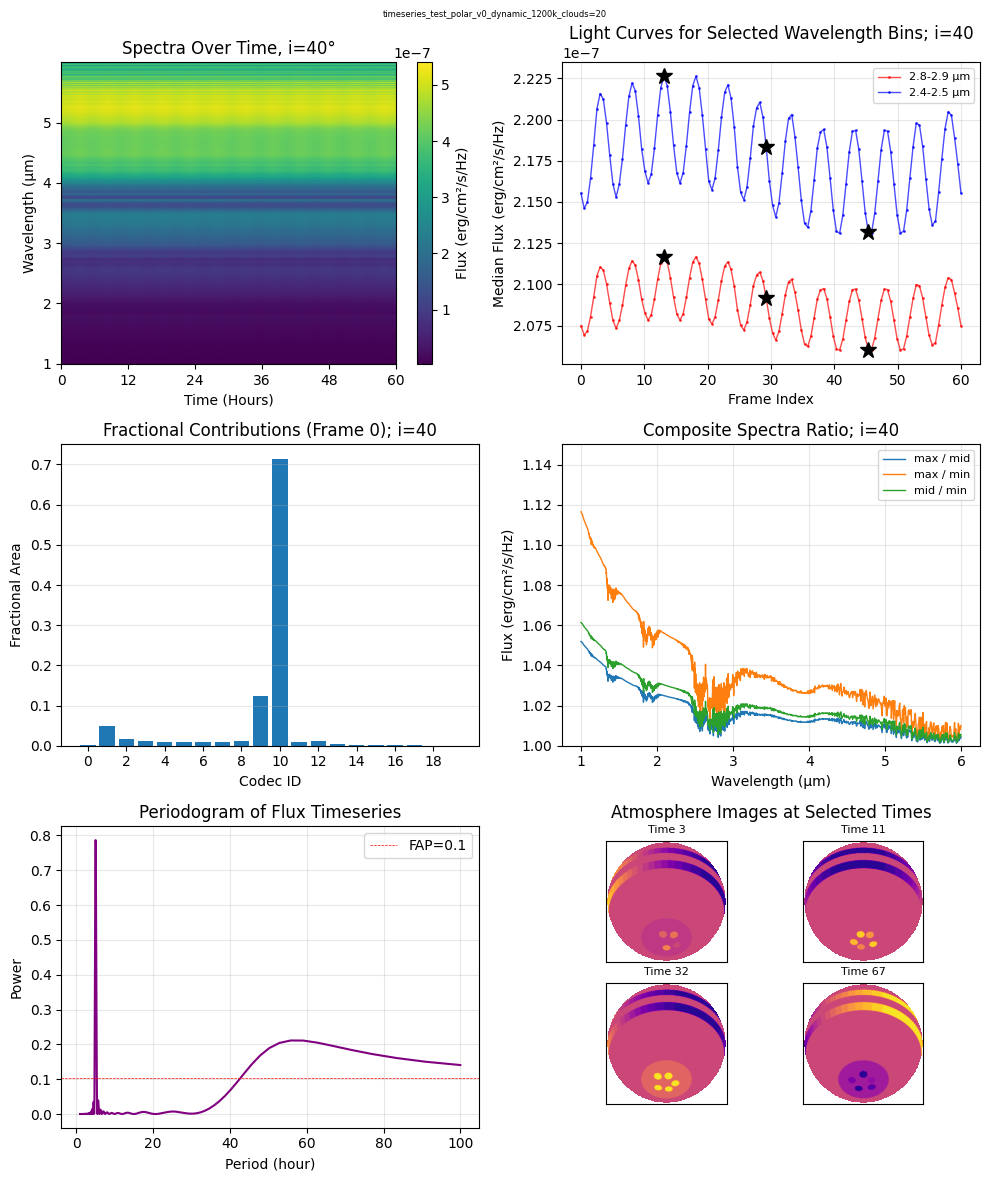


### Visualizing Spectra ###
Saved summary panel for i=50 to spectra_analysis_i=50.pdf


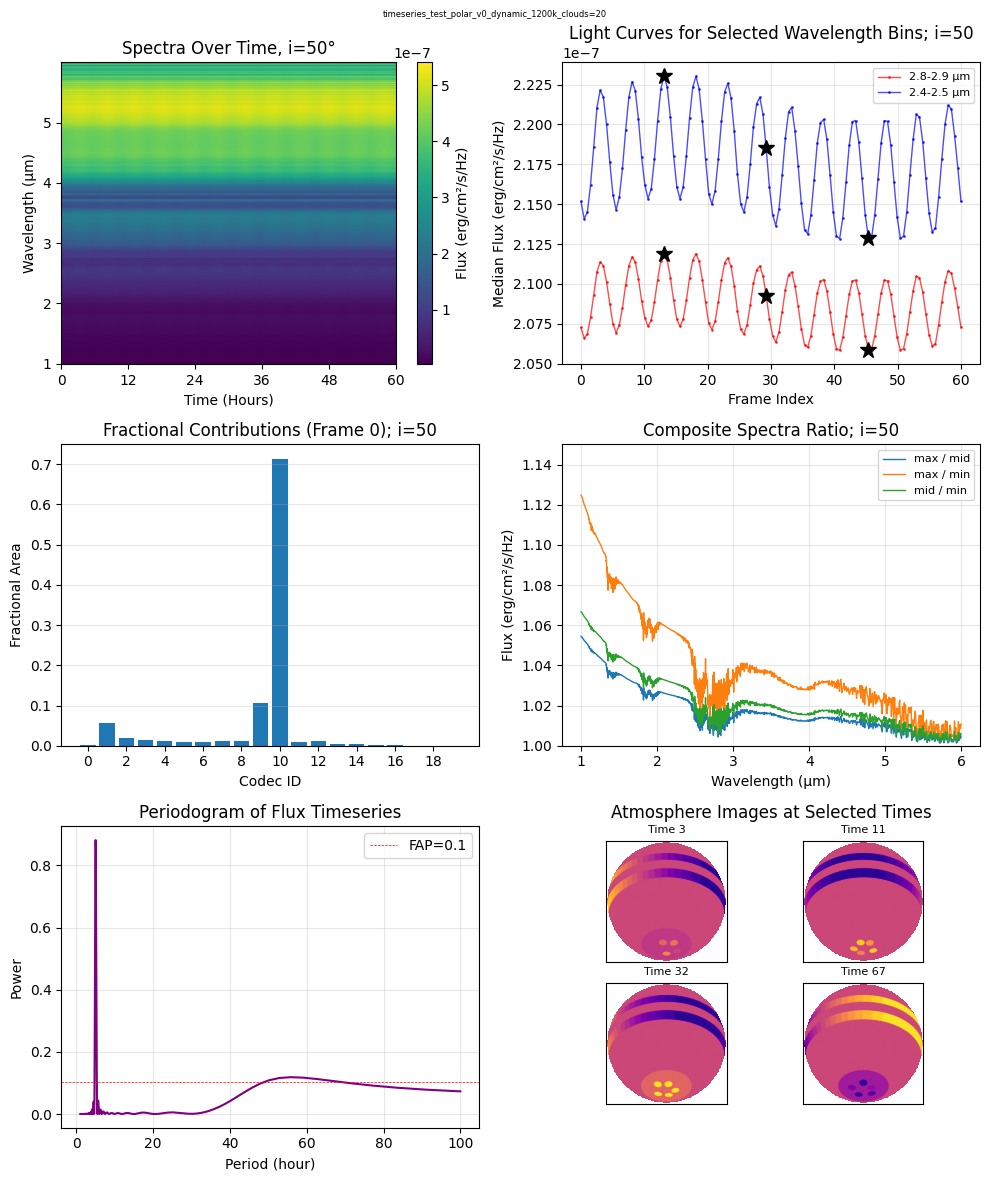


### Visualizing Spectra ###
Saved summary panel for i=60 to spectra_analysis_i=60.pdf


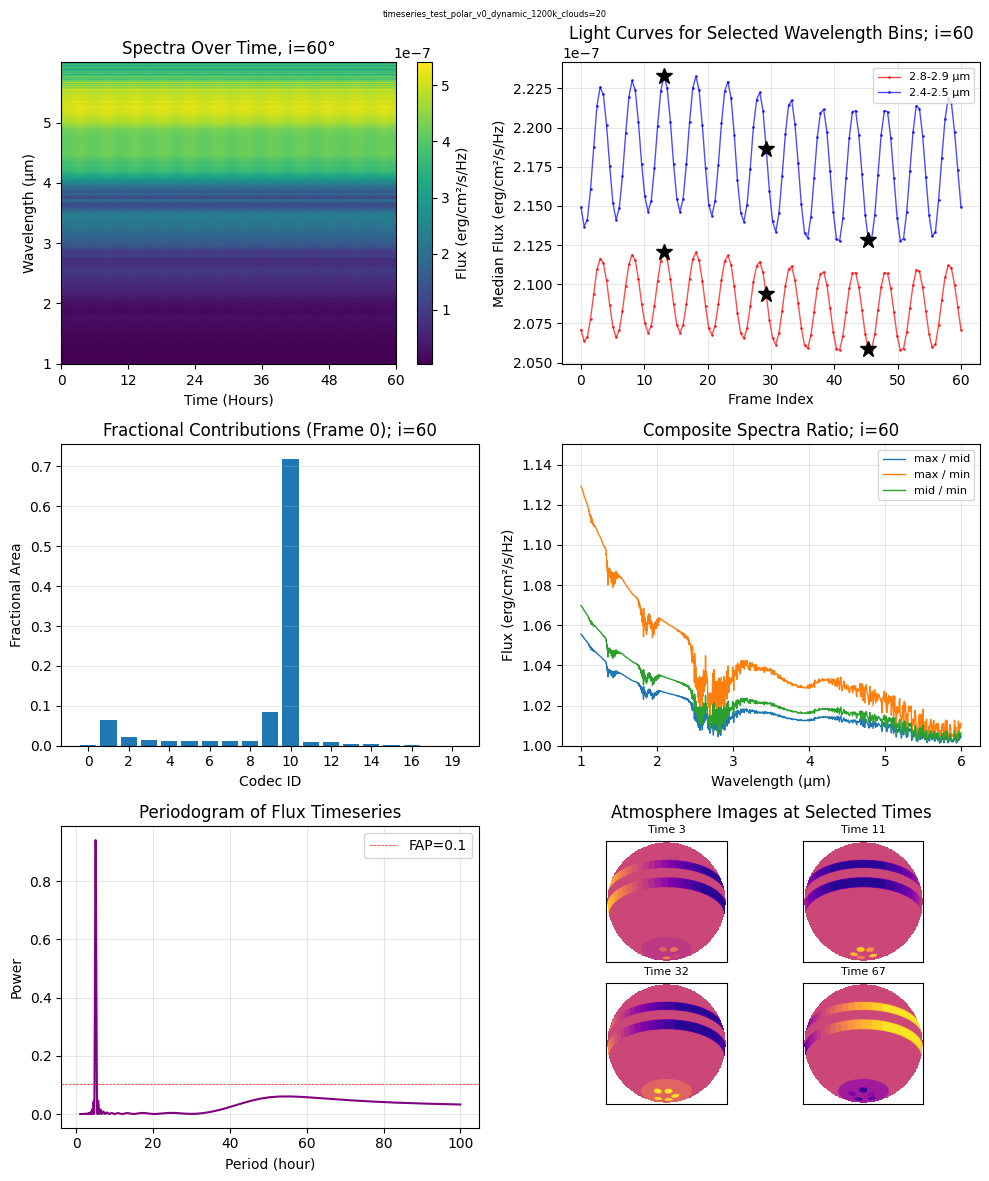


### Visualizing Spectra ###
Saved summary panel for i=70 to spectra_analysis_i=70.pdf


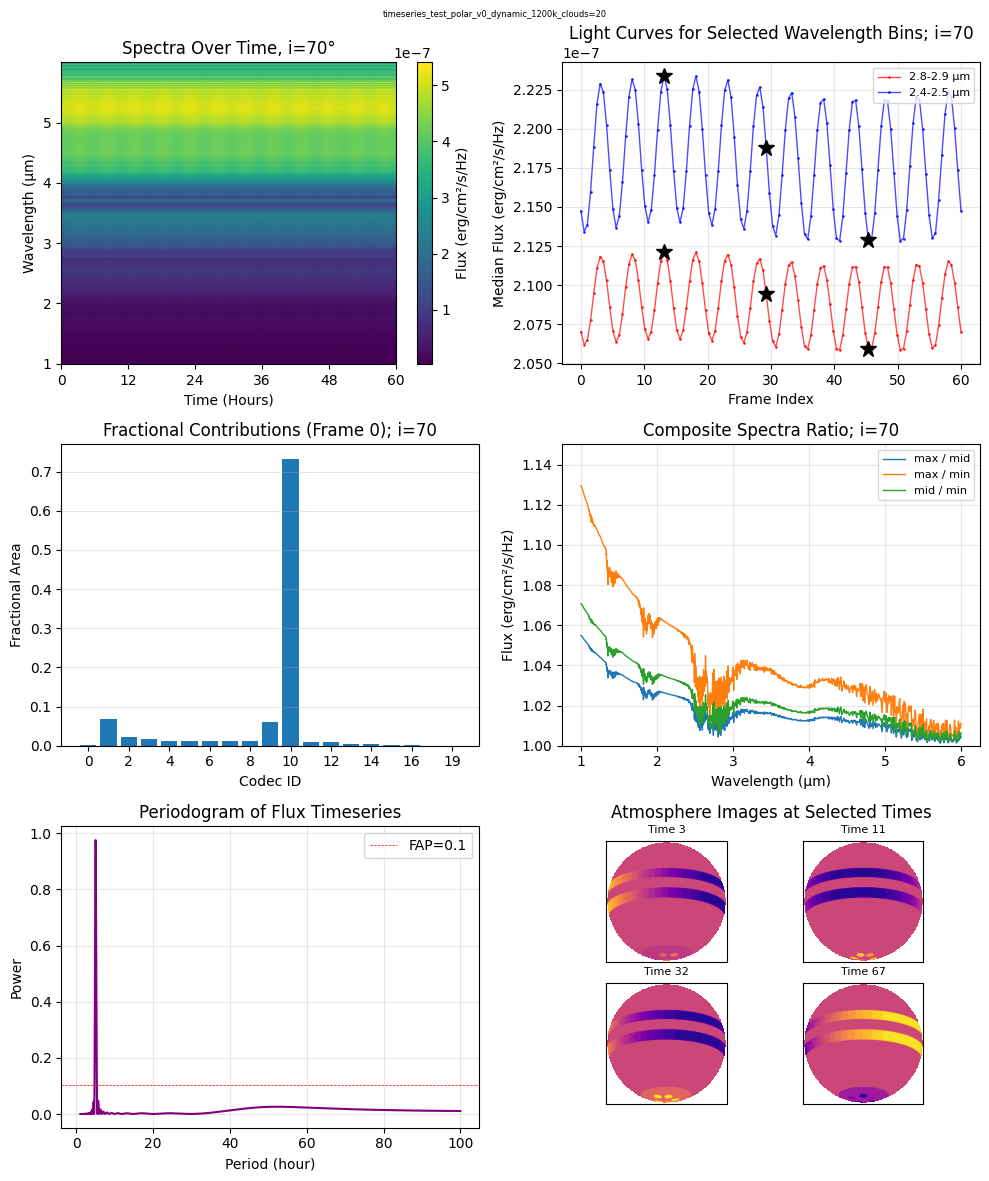


### Visualizing Spectra ###
Saved summary panel for i=80 to spectra_analysis_i=80.pdf


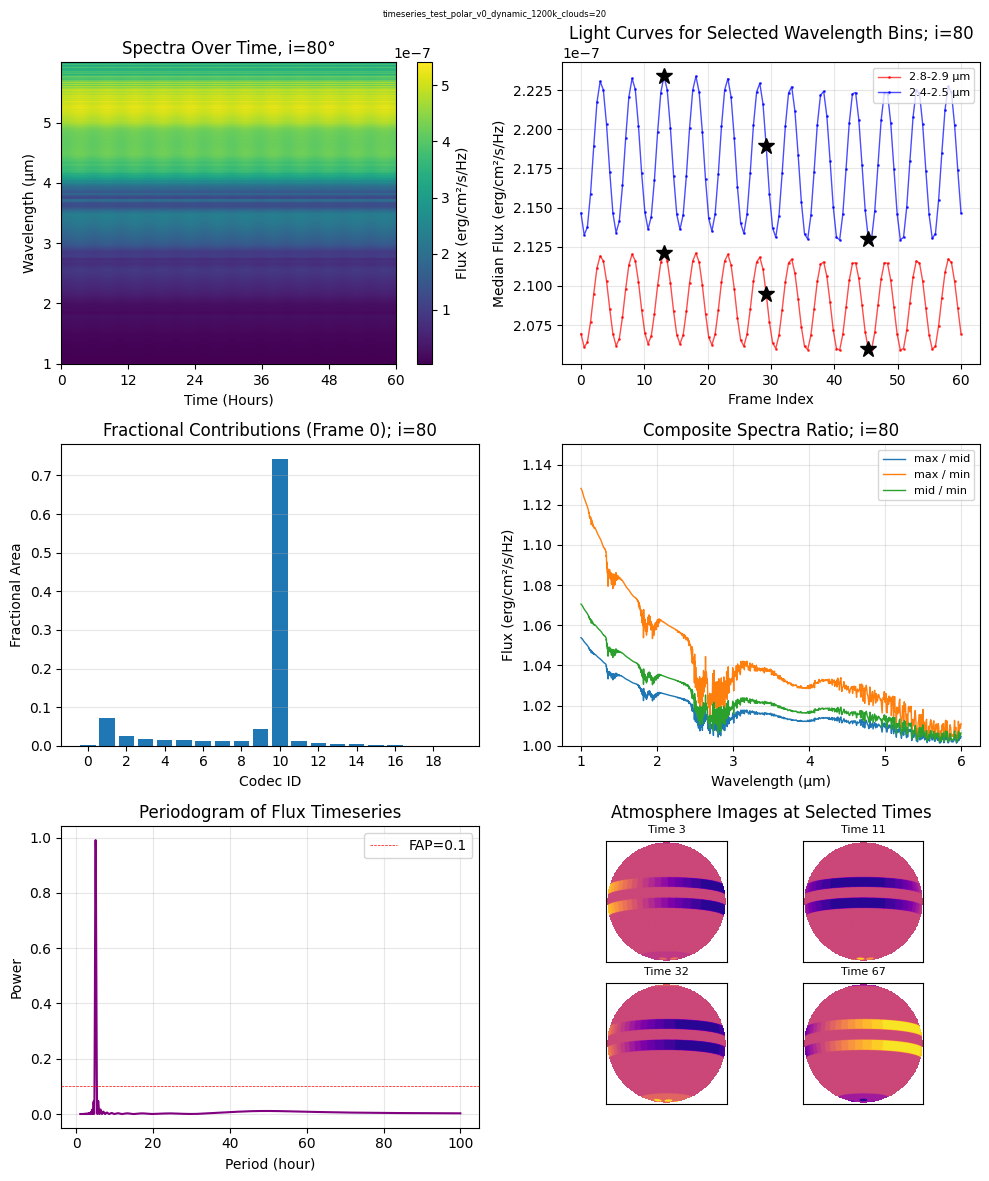


### Visualizing Spectra ###
Saved summary panel for i=90 to spectra_analysis_i=90.pdf


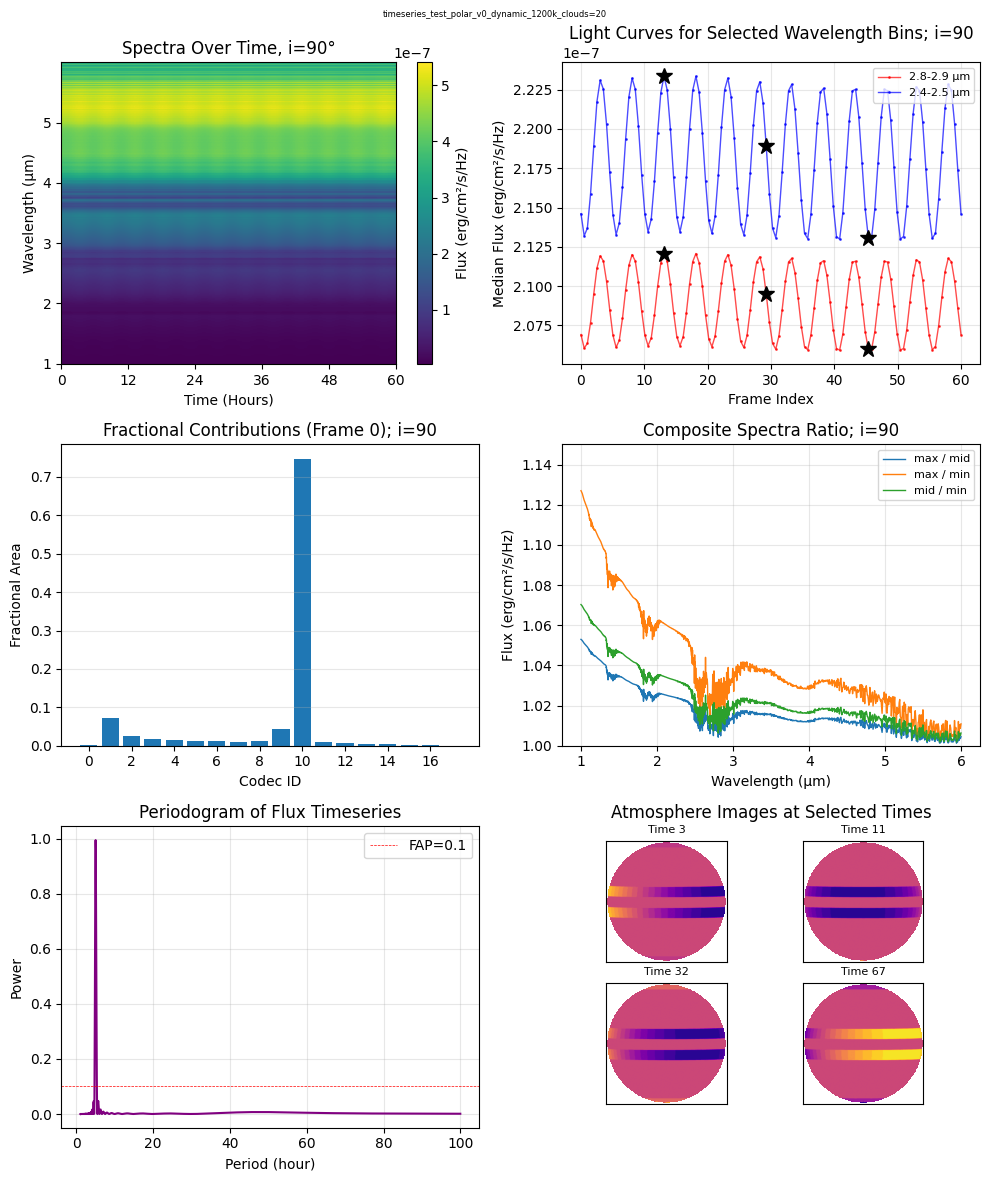

In [68]:
save = True
# save = False

######## Summary plot: Spectra, Lightcurves, Periodogram, Image ########
for inclin in specs.keys():
# for inclin in ['90']:
    composite_spectra_ts = specs[inclin]
    # ===== Visualization: Compare Individual vs Composite =====
    print("\n### Visualizing Spectra ###")

    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    fig.suptitle(runname, fontsize=6)

    # ===== Plot 1: The image of time-series spectrum =====
    ax = axes[0, 0]
    time_indices = results[inclin]['time_array']
    time_indices.sort()
    flux_matrix = []
    for keys in specs[inclin].keys():
        _, wave_i, flux_i = specs[inclin][keys].values()
        flux_matrix.append(flux_i)

    flux_matrix = np.array(flux_matrix)

    # Plot the 2D image
    im = ax.imshow(flux_matrix.T, aspect='auto', origin='lower', 
                    extent=[time_indices[0], time_indices[-1], wave_i[0], wave_i[-1]],
                    cmap='viridis')

    ax.set_xlabel('Time (Hours)')
    ax.set_xticks(np.linspace(time_indices[0], time_indices[-1], num=6, dtype=int))
    ax.set_ylabel('Wavelength (μm)')
    ax.set_title(f'Spectra Over Time, i={inclin}°')
    plt.colorbar(im, ax=ax, label='Flux (erg/cm²/s/Hz)')

    # ===== Plot 2: Light curves for specific wavelength bin =====
    ax = axes[0,1]

    # Define wavelength bins
    wavebin = [(2.8, 2.9, 'red'),
            (2.4, 2.5, 'blue'),]

    # wavebin = [(9.0, 9.5, 'pink')]

    # Extract light curves for each bin
    for wmin, wmax, color in wavebin:
        flux_timeseries = []
        
        for keys in specs[inclin]:
            frame_i, wave_i, flux_i = composite_spectra_ts[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_timeseries.append(median_flux)
        
        # Plot light curve
        ax.plot(time_indices, flux_timeseries, 
                marker='o', linestyle='-', color=color,
                alpha=0.7, 
                linewidth=1, markersize=1,
                label=f'{wmin}-{wmax} μm')

        # Highlight specific timepoint
        for i,xid in enumerate([26, 58, 90]):
            color_list = ['orange', 'green', 'purple']
            ax.plot(time_indices[xid], flux_timeseries[xid], ls='', 
                    marker='*', markersize=12, color='k')

    ax.set_xlabel('Frame Index')
    ax.set_ylabel('Median Flux (erg/cm²/s/Hz)')

    ax.set_title(f'Light Curves for Selected Wavelength Bins; i={inclin}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('linear')

    # ===== Plot 3: Fractional contributions =====

    # Process a Single Frame for Reference
    frame_idx = 0
    fractions = codecs[inclin][frame_idx]['fractions']

    ax = axes[1, 0]
    codec_ids = list(fractions['fractions'].keys())
    frac_values = list(fractions['fractions'].values())
    ax.bar(codec_ids, frac_values)
    ax.set_xlabel('Codec ID')
    ax.set_xticks(codec_ids[::2])  # Show every other tick
    ax.set_ylabel('Fractional Area')
    ax.set_title(f'Fractional Contributions (Frame {frame_idx}); i={inclin}')
    ax.grid(True, alpha=0.3, axis='y')

    # ### ===== Add inset atm images to axes[1, 1] ======
    # inset_ax = ax.inset_axes([0.05, 0.3, 0.17*1.95, 0.25*2])  # [x, y, width, height]
    # inset_ax.imshow(specs_ts[15]['composite'], cmap='plasma', aspect='auto')
    # inset_ax.set_xticks([])
    # inset_ax.set_yticks([])
    # inset_ax.set_title('Clouds-codec', fontsize=8)

    # ===== Plot 4: Composite spectra evolution over time =====
    ax = axes[1, 1]
    # for i in range(0, len(composite_spectra_ts), 10):  # Every 10th frame
    #     frame_i, wave_i, flux_i = composite_spectra_ts[i]
    #     ax.plot(wave_i, flux_i, alpha=1.0, lw=0.5, label=f'Frame {frame_i}')
    
    frameA, waveA, fluxA = composite_spectra_ts[26].values()
    frameB, waveB, fluxB = composite_spectra_ts[58].values()
    frameC, waveC, fluxC = composite_spectra_ts[90].values()

    ax.plot(waveA, fluxA/fluxB, lw=1, label=f'max / mid')
    ax.plot(waveA, fluxA/fluxC, lw=1, label=f'max / min')
    ax.plot(waveA, fluxB/fluxC, lw=1, label=f'mid / min')

    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Flux (erg/cm²/s/Hz)')
    ax.set_title(f'Composite Spectra Ratio; i={inclin}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1.0, 1.15)

    # ===== Plot 5: Periodogram of second lightcurve in hours x-axis =====
    ax = axes[2, 0]

    from PyAstronomy.pyTiming import pyPeriod
    freqs = np.linspace(0.01, 1, 1000) 
    flux_timeseries = np.array(flux_timeseries)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_indices, flux_timeseries, 0.001*flux_timeseries), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='purple')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={fap}')
    ax.set_xlabel('Period (hour)')
    ax.set_ylabel('Power')
    ax.set_title('Periodogram of Flux Timeseries')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ===== Plot 6: 2x2 images at t=0, 10, 20, 30
    ax = axes[2, 1]
    timepoints = [3, 11, 32, 67]
    n_tp = len(timepoints)
    for i, tp in enumerate(timepoints):
        img = codecs[inclin][tp]['composite']
        sub_ax = ax.inset_axes([
        0.05 + (i % 2) * 0.47, 
        0.55 - (i // 2) * 0.47, 
        0.4, 0.4
        ])
        im = sub_ax.imshow(img, cmap='plasma', vmin=0, vmax=n,
                                aspect='equal')  # Set aspect to 'equal'
        sub_ax.set_xticks([])
        sub_ax.set_yticks([])
        sub_ax.set_title(f'Time {tp}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Atmosphere Images at Selected Times')
    # set all spine frames to be invisible
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ==============================
    plt.tight_layout()
    handle = f'spectra_analysis_i={inclin}.pdf'
    save_path = os.path.join(dirPath, 'plots', handle)
    if save:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved summary panel for i={inclin} to {handle}")
    plt.show()
    plt.close()

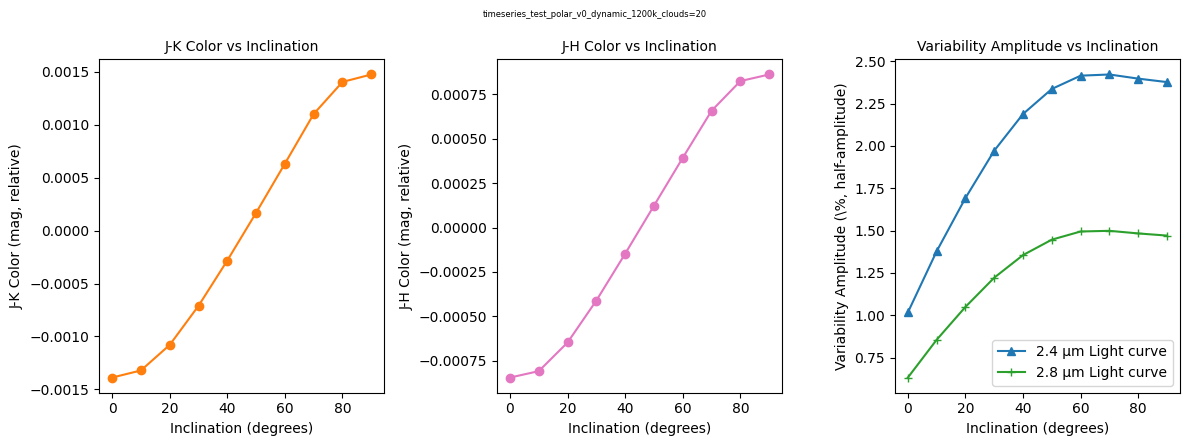

In [72]:
# ======= Relative J-K and J-H Color and variability amplitude vs Inclination Plot =======
# save = False
save = True

colorsJK, colorsJH = [], []
# get amplitudes at 2.4 and 2.8 microns
amplitudes1, amplitudes2 = [], [] 

for inclin in specs.keys():
    composite_spectra_ts = specs[inclin]
    _, wave_i, flux_i = composite_spectra_ts[0].values()
    mean_flux = np.zeros_like(wave_i)

    # Define J, H, K band masks
    color_J_mask = (wave_i >= 1.1) & (wave_i <= 1.4)
    color_H_mask = (wave_i >= 1.5) & (wave_i <= 1.8)
    color_K_mask = (wave_i >= 2.2) & (wave_i <= 2.4)

    bin1_mask = (wave_i >= 2.4) & (wave_i <= 2.5)
    bin2_mask = (wave_i >= 2.8) & (wave_i <= 2.9)

    # Get amplitude at 2.4 and 2.8 microns
    flux1, flux2 = [], []
    
    for keys in specs[inclin]:
        _, wave_i, flux_i = composite_spectra_ts[keys].values()
        
        if np.sum(mask) > 0:
            # Calculate median flux in 2.4um and 2.8um bin
            flux1.append(np.median(flux_i[bin1_mask]))
            flux2.append(np.median(flux_i[bin2_mask]))

        # Get mean flux for color calculation
        mean_flux += flux_i

    # Calculate 'color' value using mean flux within the J, H, K bands
    mean_flux /= len(specs[inclin].keys())

    color_J_flux = np.mean(mean_flux[color_J_mask])
    color_H_flux = np.mean(mean_flux[color_H_mask])
    color_K_flux = np.mean(mean_flux[color_K_mask])

    colorJK = 2.5 * np.log10(color_J_flux / color_K_flux)
    colorJH = 2.5 * np.log10(color_J_flux / color_H_flux)

    colorsJK.append((float(inclin), colorJK))
    colorsJH.append((float(inclin), colorJH))

    # Calculate variability amplitude at 2.4 and 2.8 microns
    amplitudes1.append((float(inclin), 100*(np.max(flux1) - np.min(flux1))/2 / np.mean(flux1)))
    amplitudes2.append((float(inclin), 100*(np.max(flux2) - np.min(flux2))/2 / np.mean(flux2)))

# Plot color vs inclination
fig, [ax1, ax2, ax3] = plt.subplots(1,3, figsize=(12,4.5))
fig.suptitle(runname, fontsize=6)

inclinations, JK_inc = zip(*colorsJK)
_, JH_inc = zip(*colorsJH)
_, amplitudes1_inc = zip(*amplitudes1)
_, amplitudes2_inc = zip(*amplitudes2)

JK_inc_mean, JH_inc_mean = np.mean(JK_inc), np.mean(JH_inc)
ax1.plot(inclinations, JK_inc - JK_inc_mean, marker='o', linestyle='-', 
         c='tab:orange')
ax1.set_title(f'J-K Color vs Inclination', fontsize=10)
ax1.set_xlabel('Inclination (degrees)')
ax1.set_ylabel('J-K Color (mag, relative)')

ax2.plot(inclinations, JH_inc - JH_inc_mean, marker='o', linestyle='-',
        c='tab:pink')
ax2.set_title(f'J-H Color vs Inclination', fontsize=10)
ax2.set_xlabel('Inclination (degrees)')
ax2.set_ylabel('J-H Color (mag, relative)')

# Plot variability amplitude vs inclination
ax3.plot(inclinations, amplitudes1_inc, marker='^', linestyle='-', 
         c='tab:blue', label='2.4 μm Light curve')
ax3.plot(inclinations, amplitudes2_inc, marker='+', linestyle='-',
         c='tab:green', label='2.8 μm Light curve')
ax3.set_title(f'Variability Amplitude vs Inclination', fontsize=10)
ax3.set_xlabel('Inclination (degrees)')
ax3.set_ylabel('Variability Amplitude (\%, half-amplitude)')
ax3.legend()

plt.tight_layout()
if save:
    handle = f'color_inclination_{specConfigName}.pdf'
    save_path = os.path.join(dirPath, 'plots', handle)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.show()